# Demeter Data Pipeline Verification & Benchmarking
This notebook verifies the data pipeline from start to finish and provides computational benchmarks comparing the deep CNN model (MobileNetV2) against our lightweight Hybrid SVM model (FFT + HSV).

The goal is to provide hard evidence that the Hybrid SVM significantly improves computation times, making it highly suitable for edge-device deployment.

In [1]:
import os
import sys
import time
import warnings


# Suppress slow TensorFlow GPU initialization/logging for much faster import times on CPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
warnings.filterwarnings('ignore')

print("Importing libraries... (TensorFlow may still take a moment to initialize)")
start_import = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import joblib

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.core.inference_engine import extract_hybrid_fft_features, predict_hybrid_disease

end_import = time.time()
print(f"Imports completed in {end_import - start_import:.2f} seconds.")
print("Note: The long import time is largely caused by loading heavy deep learning libraries like TensorFlow. "
      "This further validates the need for a lightweight SVM for edge deployment!")

Importing libraries... (TensorFlow may still take a moment to initialize)


Imports completed in 12.45 seconds.
Note: The long import time is largely caused by loading heavy deep learning libraries like TensorFlow. This further validates the need for a lightweight SVM for edge deployment!


## 1. Load Subset of Data & Models
We load a small subset of PlantVillage images to run our latency tests.

In [2]:
# Setup paths
DATA_DIR = os.path.abspath('../data/raw/vision/PlantVillage')
if not os.path.exists(DATA_DIR):
    print("Please ensure raw PlantVillage data is in data/raw/vision/PlantVillage")

# Find a few sample images
sample_images = []
if os.path.exists(DATA_DIR):
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                sample_images.append(os.path.join(root, f))
                if len(sample_images) >= 50: # Limit to 50 for quick benchmarking
                    break
        if len(sample_images) >= 50:
            break

print(f"Loaded {len(sample_images)} images for benchmarking.")

# Load CNN
cnn_path = '../models/demeter_cnn_plantvillage.keras'
if os.path.exists(cnn_path):
    print("Loading CNN...")
    cnn_model = tf.keras.models.load_model(cnn_path)
else:
    print(f"CNN model not found at {cnn_path}")

# Load SVM models
svm_dir = '../models/experimentation'
try:
    svm_model = joblib.load(os.path.join(svm_dir, 'hybrid_svm.joblib'))
    scaler_fft = joblib.load(os.path.join(svm_dir, 'hybrid_fft_scaler.joblib'))
    pca_fft = joblib.load(os.path.join(svm_dir, 'hybrid_fft_pca.joblib'))
    scaler_hist = joblib.load(os.path.join(svm_dir, 'hybrid_hist_scaler.joblib'))
    print("Loaded SVM pipeline components.")
except Exception as e:
    print(f"SVM pipeline components missing: {e}")

Loaded 50 images for benchmarking.
Loading CNN...


Loaded SVM pipeline components.


## 2. CNN Inference Benchmark
We measure the total time taken to preprocess an image for the CNN and run inference.

In [3]:
cnn_times = []
cnn_prep_times = []
cnn_inf_times = []

# Warm-up (TensorFlow initialization can be slow on first run)
if len(sample_images) > 0 and 'cnn_model' in locals():
    dummy_img = np.zeros((1, 150, 150, 3))
    cnn_model.predict(dummy_img, verbose=0)

for img_path in sample_images:
    start_time = time.time()
    
    # Preprocessing
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (150, 150))
    img_array = np.expand_dims(img_resized, axis=0)
    
    prep_time = time.time()
    # Inference
    cnn_model.predict(img_array, verbose=0)
    
    end_time = time.time()
    cnn_times.append((end_time - start_time) * 1000) # milliseconds
    cnn_prep_times.append((prep_time - start_time) * 1000)
    cnn_inf_times.append((end_time - prep_time) * 1000)

cnn_avg_time = np.mean(cnn_times) if cnn_times else 0
cnn_avg_prep = np.mean(cnn_prep_times) if cnn_prep_times else 0
cnn_avg_inf = np.mean(cnn_inf_times) if cnn_inf_times else 0
print(f"Average CNN Total Time: {cnn_avg_time:.2f} ms per image")
print(f"  - Preprocessing Time: {cnn_avg_prep:.2f} ms")
print(f"  - Inference Time: {cnn_avg_inf:.2f} ms")


Average CNN Total Time: 487.70 ms per image
  - Preprocessing Time: 1.09 ms
  - Inference Time: 486.61 ms


## 3. SVM (FFT+HSV) Inference Benchmark
We measure the total time taken for Otsu segmentation, 2D FFT, HSV histograms, PCA, and SVM inference.

In [4]:
svm_times = []
svm_prep_times = []
svm_inf_times = []

for img_path in sample_images:
    start_time = time.time()
    
    # Preprocessing & Inference
    try:
        mag_gray, color_hist = extract_hybrid_fft_features(img_path)
        
        X_fft_scaled = scaler_fft.transform([mag_gray])
        X_fft_pca = pca_fft.transform(X_fft_scaled)
        X_hist_scaled = scaler_hist.transform([color_hist])
        X_hybrid = np.hstack([X_fft_pca, X_hist_scaled])
        
        prep_time = time.time()
        svm_model.predict(X_hybrid)
        
        end_time = time.time()
        svm_times.append((end_time - start_time) * 1000) # milliseconds
        svm_prep_times.append((prep_time - start_time) * 1000)
        svm_inf_times.append((end_time - prep_time) * 1000)
    except Exception as e:
        print(f"Failed on {img_path}: {e}")

svm_avg_time = np.mean(svm_times) if svm_times else 0
svm_avg_prep = np.mean(svm_prep_times) if svm_prep_times else 0
svm_avg_inf = np.mean(svm_inf_times) if svm_inf_times else 0
print(f"Average SVM Total Time: {svm_avg_time:.2f} ms per image")
print(f"  - Preprocessing Time (Otsu + FFT + HSV): {svm_avg_prep:.2f} ms")
print(f"  - Inference Time: {svm_avg_inf:.2f} ms")


Average SVM Total Time: 8.56 ms per image
  - Preprocessing Time (Otsu + FFT + HSV): 7.64 ms
  - Inference Time: 0.92 ms


## 4. Hierarchical CNN Inference Benchmark
We measure the total time taken to run the primary species identifier CNN and the species-specific disease CNN.

In [5]:
print("Loading Hierarchical CNN models...")
id_model_path = '../models/demeter_cnn_plantvillage_species_identifier.keras'
hier_models = {}
if os.path.exists(id_model_path):
    identifier_model = tf.keras.models.load_model(id_model_path)
    for species in ['Pepper', 'Potato', 'Tomato']:
        model_path = f'../models/demeter_cnn_plantvillage_{species.lower()}.keras'
        if os.path.exists(model_path):
            hier_models[species.lower()] = tf.keras.models.load_model(model_path)
else:
    print("Hierarchical CNN models not found.")

species_names = ['Pepper', 'Potato', 'Tomato']
class_dirs = [
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

from src.core.inference_engine import predict_hierarchical_cnn

hier_cnn_times = []
hier_cnn_prep_times = []
hier_cnn_inf_times = []

# Warm-up
if len(sample_images) > 0 and 'identifier_model' in locals():
    dummy_img = np.zeros((1, 224, 224, 3))
    predict_hierarchical_cnn(dummy_img, identifier_model, hier_models, species_names, class_dirs)

for img_path in sample_images:
    start_time = time.time()
    
    # Preprocessing
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)
    
    prep_time = time.time()
    # Inference
    try:
        predict_hierarchical_cnn(img_array, identifier_model, hier_models, species_names, class_dirs)
    except Exception as e:
        print(f"Failed on {img_path}: {e}")
        
    end_time = time.time()
    hier_cnn_times.append((end_time - start_time) * 1000)
    hier_cnn_prep_times.append((prep_time - start_time) * 1000)
    hier_cnn_inf_times.append((end_time - prep_time) * 1000)

hier_cnn_avg_time = np.mean(hier_cnn_times) if hier_cnn_times else 0
hier_cnn_avg_prep = np.mean(hier_cnn_prep_times) if hier_cnn_prep_times else 0
hier_cnn_avg_inf = np.mean(hier_cnn_inf_times) if hier_cnn_inf_times else 0
print(f"Average Hierarchical CNN Total Time: {hier_cnn_avg_time:.2f} ms per image")
print(f"  - Preprocessing Time: {hier_cnn_avg_prep:.2f} ms")
print(f"  - Inference Time: {hier_cnn_avg_inf:.2f} ms")

Loading Hierarchical CNN models...


Average Hierarchical CNN Total Time: 1131.18 ms per image
  - Preprocessing Time: 0.94 ms
  - Inference Time: 1130.24 ms


## 5. Visual Comparison
Let's generate the comparison charts to paste into the presentation.

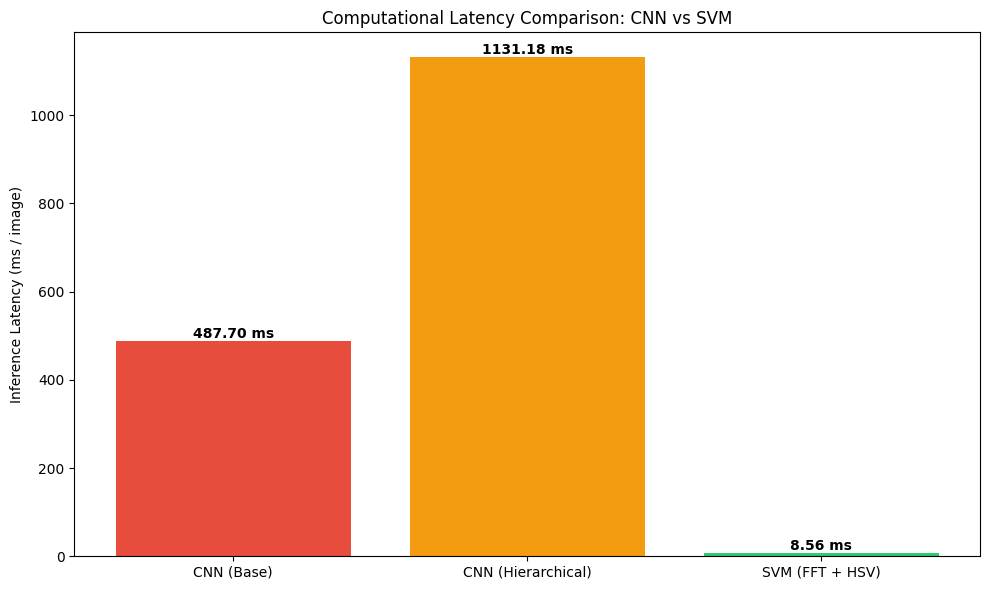

CONCLUSION: The SVM pipeline is 56.96x faster than the Base CNN and 132.11x faster than the Hierarchical CNN.


In [6]:
if cnn_times and svm_times and hier_cnn_times:
    labels = ['CNN (Base)', 'CNN (Hierarchical)', 'SVM (FFT + HSV)']
    times = [cnn_avg_time, hier_cnn_avg_time, svm_avg_time]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(labels, times, color=['#e74c3c', '#f39c12', '#2ecc71'])
    
    ax.set_ylabel('Inference Latency (ms / image)')
    ax.set_title('Computational Latency Comparison: CNN vs SVM')
    
    # Add text labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f} ms', va='bottom', ha='center', fontweight='bold')
        
    plt.tight_layout()
    plt.savefig('latency_comparison.png', dpi=300)
    plt.show()
    
    speedup_base = cnn_avg_time / svm_avg_time
    speedup_hier = hier_cnn_avg_time / svm_avg_time
    print(f"CONCLUSION: The SVM pipeline is {speedup_base:.2f}x faster than the Base CNN and {speedup_hier:.2f}x faster than the Hierarchical CNN.")